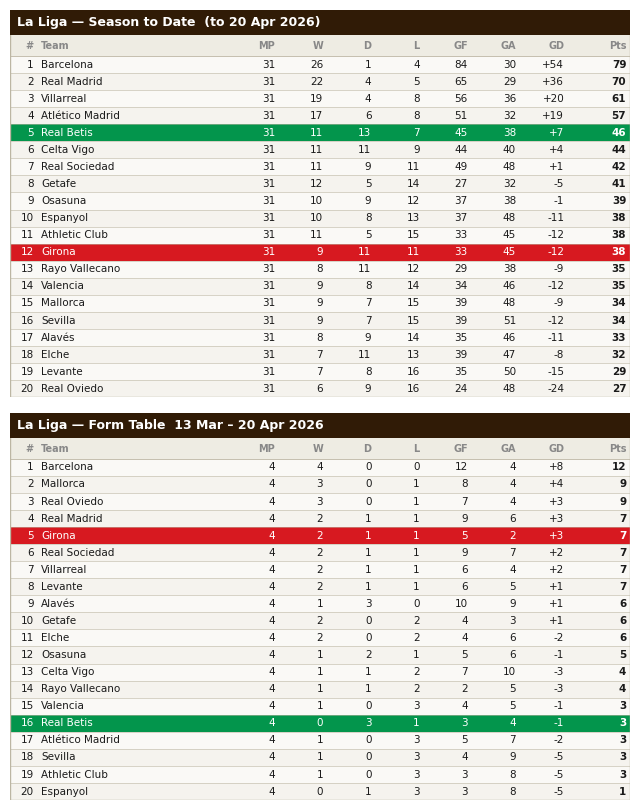

Saved → league_table_present.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── colour tokens (mirrors lineup.py / constants.py) ──────────────────────────
CARD_BG     = "#FAF9F6"
BORDER      = "#BCB6A3"
TEXT_MAIN   = "#1A1A1A"
TEXT_MUTED  = "#888888"
LALIGA_RED  = "#301B06"
_TBL_HDR_BG = "#EEECE3"
_ROW_ALT_BG = "#F5F3EE"

# ── load data ──────────────────────────────────────────────────────────────────
colours     = pd.read_csv("laliga_team_colour_1.csv")
match_dates = pd.read_csv("../1_Downloader/laliga_0524_1.csv", encoding="utf-8-sig")
stats       = pd.read_csv("../2_Data/laliga_stats/team_stats_per_match.csv")

match_dates["date"] = pd.to_datetime(match_dates["date"], dayfirst=True)
merged = stats.merge(match_dates[["match_id", "date"]], on="match_id", how="left")

# stats team_name → display name (colour CSV + manual overrides for mismatched keys)
_DISPLAY = dict(zip(colours["team_full_name"], colours["team_display_name"]))
_DISPLAY.update({
    "Club Atlético de Madrid":                   "Atlético Madrid",
    "Real Club Celta de Vigo":                   "Celta Vigo",
    "Reial Club Deportiu Espanyol de Barcelona": "Espanyol",
    "Real Club Deportivo Mallorca":               "Mallorca",
    "Rayo Vallecano de Madrid":                  "Rayo Vallecano",
    "Real Sociedad de Fútbol":                   "Real Sociedad",
})

# row highlights: display name → (background hex, text hex)
HIGHLIGHTS = {
    "Girona":    ("#D71920", "#FFFFFF"),
    "Real Betis": ("#03954C", "#FFFFFF"),
}

# ── build league table ─────────────────────────────────────────────────────────
def build_table(df):
    g = (
        df.groupby("team_name")
        .agg(MP=("match_id", "count"), W=("win", "sum"), D=("draw", "sum"),
             L=("loss", "sum"), GF=("goals_for", "sum"), GA=("goals_against", "sum"),
             Pts=("points", "sum"))
        .reset_index()
    )
    g["GD"]   = g["GF"] - g["GA"]
    g["Team"] = g["team_name"].map(_DISPLAY).fillna(g["team_name"])
    g = g.sort_values(["Pts", "GD", "GF"], ascending=False).reset_index(drop=True)
    g.insert(0, "#", range(1, len(g) + 1))
    return g[["#", "Team", "MP", "W", "D", "L", "GF", "GA", "GD", "Pts"]]

CUT1   = pd.Timestamp("2026-04-20")
START2 = pd.Timestamp("2026-03-13")

table_full   = build_table(merged[merged["date"] <= CUT1])
table_window = build_table(merged[(merged["date"] >= START2) & (merged["date"] <= CUT1)])

# ── table renderer ─────────────────────────────────────────────────────────────
_COL_RAW_W = {"#": 4, "Team": 28, "MP": 7, "W": 7, "D": 7, "L": 7,
              "GF": 7, "GA": 7, "GD": 7, "Pts": 9}
_TOTAL_W   = sum(_COL_RAW_W.values())

TITLE_H  = 1.5
HEADER_H = 1.2
ROW_H    = 1.0

def _tbl_h(n): return TITLE_H + HEADER_H + n * ROW_H


def draw_table(ax, df, title):
    cols  = list(df.columns)
    n     = len(df)
    tot_h = _tbl_h(n)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, tot_h)
    ax.axis("off")

    # column x positions
    cx, cw = {}, {}
    x = 0
    for c in cols:
        cw[c] = _COL_RAW_W[c] / _TOTAL_W
        cx[c] = x
        x += cw[c]

    y = tot_h  # draw top → bottom

    # title bar
    y -= TITLE_H
    ax.add_patch(patches.Rectangle(
        (0, y), 1, TITLE_H, facecolor=LALIGA_RED, edgecolor="none", zorder=2))
    ax.text(0.012, y + TITLE_H * 0.5, title,
            va="center", ha="left", fontsize=9, fontweight="bold",
            color="white", zorder=3)

    # header row
    y -= HEADER_H
    ax.add_patch(patches.Rectangle(
        (0, y), 1, HEADER_H, facecolor=_TBL_HDR_BG, edgecolor="none"))
    ax.plot([0, 1], [y, y], color=BORDER, lw=0.6)
    for c in cols:
        right = (c != "Team")
        tx = cx[c] + cw[c] - 0.006 if right else cx[c] + 0.006
        ax.text(tx, y + HEADER_H * 0.5, c,
                va="center", ha="right" if right else "left",
                fontsize=7, fontweight="bold", color=TEXT_MUTED)

    # data rows
    for i, (_, row) in enumerate(df.iterrows()):
        y -= ROW_H
        team = row["Team"]
        if team in HIGHLIGHTS:
            bg, fg = HIGHLIGHTS[team]
        elif i % 2 == 1:
            bg, fg = _ROW_ALT_BG, TEXT_MAIN
        else:
            bg, fg = CARD_BG, TEXT_MAIN

        ax.add_patch(patches.Rectangle(
            (0, y), 1, ROW_H, facecolor=bg, edgecolor="none"))
        ax.plot([0, 1], [y, y], color=BORDER, lw=0.4)

        for c in cols:
            val = row[c]
            if c == "GD":
                s = f"+{int(val)}" if val > 0 else str(int(val))
            elif c == "Team":
                s = str(val)
            else:
                s = str(int(val))
            right = (c != "Team")
            tx = cx[c] + cw[c] - 0.006 if right else cx[c] + 0.006
            fw = "bold" if c == "Pts" else "normal"
            ax.text(tx, y + ROW_H * 0.5, s,
                    va="center", ha="right" if right else "left",
                    fontsize=7.5, fontweight=fw, color=fg)

    # outer border
    ax.add_patch(patches.Rectangle(
        (0, 0), 1, tot_h, facecolor="none", edgecolor=BORDER, lw=1))


# ── figure ──────────────────────────────────────────────────────────────────────
n1, n2 = len(table_full), len(table_window)
h1, h2 = _tbl_h(n1), _tbl_h(n2)

inch_per_unit = 0.215
fig_h = (h1 + h2) * inch_per_unit + 0.5

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, fig_h),
    gridspec_kw={"height_ratios": [h1, h2], "hspace": 0.04},
    facecolor="white",
)

draw_table(ax1, table_full,   "La Liga — Season to Date  (to 20 Apr 2026)")
draw_table(ax2, table_window, "La Liga — Form Table  13 Mar – 20 Apr 2026")

out_path = "league_table_present.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"Saved → {out_path}")